# Implementation of Trajectory Tracing via Curvature Matching

**Reference:** *Morphing of and writing with a scissor linkage mechanism*, Mohanraj A. and S. Ganga Prasath.

This notebook implements the differentiable simulation framework to solve the inverse kinematics problem for a scissor linkage. The objective is to identify mechanism design parameters that reproduce a prescribed planar trajectory by matching its intrinsic curvature profile. 

The pipeline converts raw target coordinate data into an arc-length parameterized curvature representation, simulates the mechanism actuation through a forward kinematic model, and optimizes the design parameters using gradient-based methods enabled by automatic differentiation.

## 1. Target shape processing and extracting curvature

**Theory:**
The target trajectory is provided as an ordered set of planar coordinates $\{(x_i, y_i)\}_{i=1}^N$. To enable a pointwise error metric, we:
1. Normalize the coordinates to a unit bounding box while preserving the aspect ratio.
2. Construct an arc-length parameterization $s \in [0, 1]$.
3. Compute the associated smoothed target curvature profile, denoted by $\kappa^t(s)$, sampled on a uniform grid.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# ==============================================================================
# 1. HELPER FUNCTIONS (Target Generation & Resampling)
# ==============================================================================

def get_sine_target_curvature(device, A=0.25, n_waves=1.0, N=100):
    """Generates a sine curve target and its curvature."""
    x = np.linspace(0, 1, N)
    y = A * np.sin(2 * np.pi * n_waves * x)

    dx = np.gradient(x)
    dy = np.gradient(y)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.cumsum(ds)
    s -= s[0]

    total_len = s[-1]
    s_norm = s / s[-1]

    x_s = np.gradient(x, s_norm)
    y_s = np.gradient(y, s_norm)
    x_ss = np.gradient(x_s, s_norm)
    y_ss = np.gradient(y_s, s_norm)

    # Curvature formula based on spatial derivatives
    kappa = (x_s * y_ss - y_s * x_ss) / ((x_s**2 + y_s**2)**1.5 + 1e-8)

    return (
        torch.tensor(kappa, dtype=torch.float32).to(device),
        x, y,
        torch.tensor(total_len, dtype=torch.float32).to(device)
    )

def get_real_target_curvature(device):
    """
    Processes discrete coordinate data (e.g., the 'j' character from the writing task).
    Normalizes coordinates and computes smooth curvature profile using Splines.
    """
    # j char coordinates
    x_np = np.array([226.71276596, 212.41489362, 190.96808511, 180.24468085, 175.13829787,
                 166.45744681, 154.71276596, 144.5, 129.69148936, 113.35106383,
                 105.69148936, 103.64893617, 105.18085106, 117.94680851, 140.92553191,
                 161.86170213, 190.96808511, 222.11702128, 267.56382979])

    y_np = -1*np.array([49.26595745, 147.81914894, 237.69148936, 287.22340426, 296.41489362,
                 309.69148936, 320.41489362, 327.05319149, 329.60638298, 326.54255319,
                 318.88297872, 305.09574468, 289.26595745, 272.92553191, 253.5212766,
                 238.71276596, 221.35106383, 202.45744681, 174.37234043])

    # Rescale to unit box
    x_min, x_max = x_np.min(), x_np.max()
    y_min, y_max = y_np.min(), y_np.max()
    width, height = x_max - x_min, y_max - y_min
    target_scale = 1.0
    scale = min(target_scale / width, target_scale / height)
    x = (x_np - x_min) * scale
    y = (y_np - y_min) * scale

    # Arc length parameterization
    dx_diff = np.diff(x)
    dy_diff = np.diff(y)
    ds = np.sqrt(dx_diff**2 + dy_diff**2)
    s = np.concatenate([[0], np.cumsum(ds)])
    
    # --- Capture Target Length ---
    total_len = s[-1]
    
    s_norm = s / s.max()

    x_s = np.gradient(x, s_norm)
    y_s = np.gradient(y, s_norm)
    x_ss = np.gradient(x_s, s_norm)
    y_ss = np.gradient(y_s, s_norm)
    
    # Raw curvature
    kappa_raw = (x_s * y_ss - y_s * x_ss) / ((x_s**2 + y_s**2)**1.5 + 1e-8)

    # Smoothing (Preprocessing step to extract smoothed target curvature profile)
    spl = UnivariateSpline(s_norm, kappa_raw, s=3.0) 
    s_dense = np.linspace(0, 1, 100)
    kappa_smooth = spl(s_dense)
    
    return (torch.tensor(kappa_smooth, dtype=torch.float32).to(device), 
            x, y, 
            torch.tensor(total_len, dtype=torch.float32).to(device))

def resample_to_target(kappa_model, s_model, s_target):
    """
    Linearly interpolate kappa_model(s_model) onto s_target. 
    Implements 'Arc-length alignment' mapping mechanism curvature onto the fixed target grid.
    Fully differentiable to allow gradient backpropagation.
    """
    s_target = torch.clamp(s_target, s_model[0], s_model[-1])
    idx = torch.searchsorted(s_model, s_target)

    idx0 = torch.clamp(idx - 1, min=0)
    idx1 = torch.clamp(idx, max=len(s_model) - 1)

    s0 = s_model[idx0]
    s1 = s_model[idx1]
    k0 = kappa_model[idx0]
    k1 = kappa_model[idx1]

    w = (s_target - s0) / (s1 - s0 + 1e-8)
    return (1 - w) * k0 + w * k1


## 2. Differentiable forward model and arc-length reparameterization

**Theory:**
The mechanism geometry is naturally parameterized by an actuation variable $\Psi$, whereas the target curvature is defined with respect to arc length. 

1. **Forward kinematics:** Given a set of design parameters $\boldsymbol{\theta} = \{\alpha_1,\dots,\alpha_M, l\}$, the forward kinematics generates the tip trajectory $\mathbf{r}_{\mathrm{tip}}(\Psi) = (x(\Psi), y(\Psi))$ over an actuation angle grid $\boldsymbol{\Psi} = [\Psi_0, \dots, \Psi_K]$. Note that the optimization variables $\{\tilde{\alpha}_j\} \in \mathbb{R}^M$ and $\tilde{l} \in \mathbb{R}$ are unconstrained but mapped via a smooth transformation (sigmoid/exp) to physically meaningful bounds: $\alpha_j \in [\alpha_{\min}, \alpha_{\max}]$.
2. **Curvature of the mechanism:** The trajectory is reparameterized by arc length. We compute the cumulative arc length $s^M_k(\boldsymbol{\theta})$, normalize it to $[0,1]$, and evaluate the intrinsic curvature $\kappa_{\mathrm{tip}}(s_k)$ using differentiable finite differences.
3. **Arc-length alignment:** Since $s^M(\boldsymbol{\theta})$ depends on the design parameters, the discrete samples do not coincide with the fixed target grid $\{s_k^t\}$. We interpolate the computed values onto $\{s_k^t\}$ to obtain the resampled curvature vector $\tilde{\boldsymbol{\kappa}}_{\mathrm{tip}}(\boldsymbol{\theta})$. This enables a pointwise error comparison with $\boldsymbol{\kappa}^t$.

In [5]:
# ==============================================================================
# 2. OPTIMIZED MODEL
# ==============================================================================
class StaticDesignOptimizer(nn.Module):
    def __init__(self, n_units=30, steps=100, psi_range=(178, 45)):
        super().__init__()
        self.n_units = n_units
        self.steps = steps
        # Learnable scale factor l (mapped via exponential)
        self.log_l = nn.Parameter(torch.tensor(0.5)) 
        # Learnable geometric parameters alpha (mapped via sigmoid)
        self.alpha_params = nn.Parameter(torch.randn(n_units) * 0.05)
        
        # Actuation sweep (Psi)
        Psi_deg = np.linspace(psi_range[0], psi_range[1], steps)
        self.register_buffer('Psi_vals', torch.tensor(np.deg2rad(Psi_deg), dtype=torch.float32))

    def get_alpha(self):
        # Maps unbounded parameters to (0.05, 0.95) to ensure geometric validity
        return 0.05 + 0.9 * torch.sigmoid(self.alpha_params)

    # Fast Vectorized Forward Pass (No Python loops)
    def forward(self):
        a = self.get_alpha().unsqueeze(0).expand(self.steps, -1)
        Psi = self.Psi_vals.unsqueeze(1) 
        eps = 1e-9
        
        # 1. Solve for internal angle phi based on geometry
        # (Implicitly solving the angle recursion using the law of cosines)
        a0 = a[:, 0:1] 
        d_sq = a0**2 + (1-a0)**2 - 2*a0*(1-a0)*torch.cos(Psi) 
        
        term_num = a**2 + (1-a)**2 - d_sq 
        term_den = 2*a*(1-a) + 1e-6
        cosv = torch.clamp(term_num / term_den, -1.0 + eps, 1.0 - eps)
        phi = torch.acos(cosv)
        
        # Enforce exact match for first unit (Actuation input)
        phi = torch.cat([Psi, phi[:, 1:]], dim=1)
        
        # 2. Compute effective rotation angle phi*
        angle_in = torch.clamp((np.pi - phi)/2, 0.01, 1.56)
        phi_s = 2 * torch.atan((2*a - 1) * torch.tan(angle_in))

        # 3. Accumulate absolute orientations
        if self.n_units > 1:
            shifted_c_phi = torch.cat([
                torch.zeros_like(phi_s[:, 0:1]), 
                torch.cumsum(phi_s[:, 1:-1], dim=1)
            ], dim=1)
            
            # Vector orientations T1 and T2
            T1_rest = -(shifted_c_phi + 0.5 * (phi_s[:, 1:] - phi[:, 1:] + phi_s[:, 0:1]))
            T2_rest = -(shifted_c_phi + 0.5 * (phi_s[:, 1:] + phi[:, 1:] + phi_s[:, 0:1]))
            
            T1 = torch.cat([Psi / 2, T1_rest], dim=1)
            T2 = torch.cat([-Psi / 2, T2_rest], dim=1)
        else:
            T1, T2 = Psi / 2, -Psi / 2
        
        # 4. Compute Tip Position via forward kinematics
        rx = torch.sum(a[:, :-1] * torch.cos(T1[:, :-1]), dim=1) + torch.sum(a[:, 1:] * torch.cos(T2[:, 1:]), dim=1)
        ry = torch.sum(a[:, :-1] * torch.sin(T1[:, :-1]), dim=1) + torch.sum(a[:, 1:] * torch.sin(T2[:, 1:]), dim=1)

        traj = torch.exp(self.log_l) * torch.stack([rx, ry], dim=1)
        return traj, phi

    # Fast Parameter-Invariant Curvature
    def compute_curvature_arclength(self, traj):
        """
        Calculates intrinsic curvature of the mechanism trajectory.
        """
        v = torch.gradient(traj, dim=0)[0]  
        a = torch.gradient(v, dim=0)[0]     
        
        dx, dy = v[:, 0], v[:, 1]
        ddx, ddy = a[:, 0], a[:, 1]
        
        # Compute curvature
        kappa = (dx * ddy - dy * ddx) / ((dx**2 + dy**2).pow(1.5) + 1e-8)
        
        d_traj = torch.diff(traj, dim=0)
        ds = torch.norm(d_traj, dim=1)
        s = torch.cat([torch.zeros(1, device=traj.device), torch.cumsum(ds, dim=0)])
        s = s / (s[-1] + 1e-8)

        return kappa, s


## 3. Gradient evaluation using automatic differentiation

**Theory:**
The error is defined as a composite objective containing curvature mismatch, smoothness regularization, arc-length consistency, and a steric penalty:

$$
\mathcal{L}[\boldsymbol{\theta}] = \left\| \tilde{\boldsymbol{\kappa}}_{\mathrm{tip}} - \boldsymbol{\kappa}^t \right\|^2 + \lambda_{\mathrm{sm}} \left\| \nabla \boldsymbol{\alpha} \right\|_2^2 + \lambda_{L} \left( \frac{L - L^t}{L^t} \right)^2 + \lambda_{\phi} \sum_{k=0}^K \sum_{j=1}^M \Big(\max\big(0, \phi_{\min} - \phi_j(\Psi_k)\big)\Big)^2
$$

Where:
*   $\boldsymbol{\alpha} = \{\alpha_j\}$, $L$ and $L^t$ denote the total mechanism length and the target arc length.
*   The final term enforces a soft feasibility constraint to penalize configurations where $\phi_j(\Psi_k) < \phi_{\min}$, avoiding near-singular configurations.

Using PyTorch, we compute $\nabla_{\boldsymbol{\theta}} \mathcal{L}$ efficiently through the computational graph using the Adam optimizer.

Target Length: 2.0320
Starting Optimization...
Epoch 0000 | Total Loss: 29308.7949 | Min Phi (deg): 44.73 | k_mse: 13.52
Epoch 1000 | Total Loss: 0.7834 | Min Phi (deg): 45.00 | k_mse: 0.78
Epoch 2000 | Total Loss: 0.6157 | Min Phi (deg): 45.00 | k_mse: 0.61
Epoch 3000 | Total Loss: 0.4622 | Min Phi (deg): 12.86 | k_mse: 0.43
Epoch 4000 | Total Loss: 0.3755 | Min Phi (deg): 11.15 | k_mse: 0.38
Epoch 5000 | Total Loss: 0.4243 | Min Phi (deg): 11.42 | k_mse: 0.42
Epoch 6000 | Total Loss: 0.3420 | Min Phi (deg): 10.77 | k_mse: 0.34
Epoch 7000 | Total Loss: 0.3427 | Min Phi (deg): 11.05 | k_mse: 0.34
Epoch 8000 | Total Loss: 0.3655 | Min Phi (deg): 11.39 | k_mse: 0.36
Epoch 9000 | Total Loss: 0.6715 | Min Phi (deg): 9.89 | k_mse: 0.33
Epoch 10000 | Total Loss: 0.3248 | Min Phi (deg): 10.01 | k_mse: 0.32
Epoch 11000 | Total Loss: 0.4099 | Min Phi (deg): 11.28 | k_mse: 0.41
Epoch 12000 | Total Loss: 0.3568 | Min Phi (deg): 10.13 | k_mse: 0.35
Epoch 13000 | Total Loss: 0.3237 | Min Phi (deg):

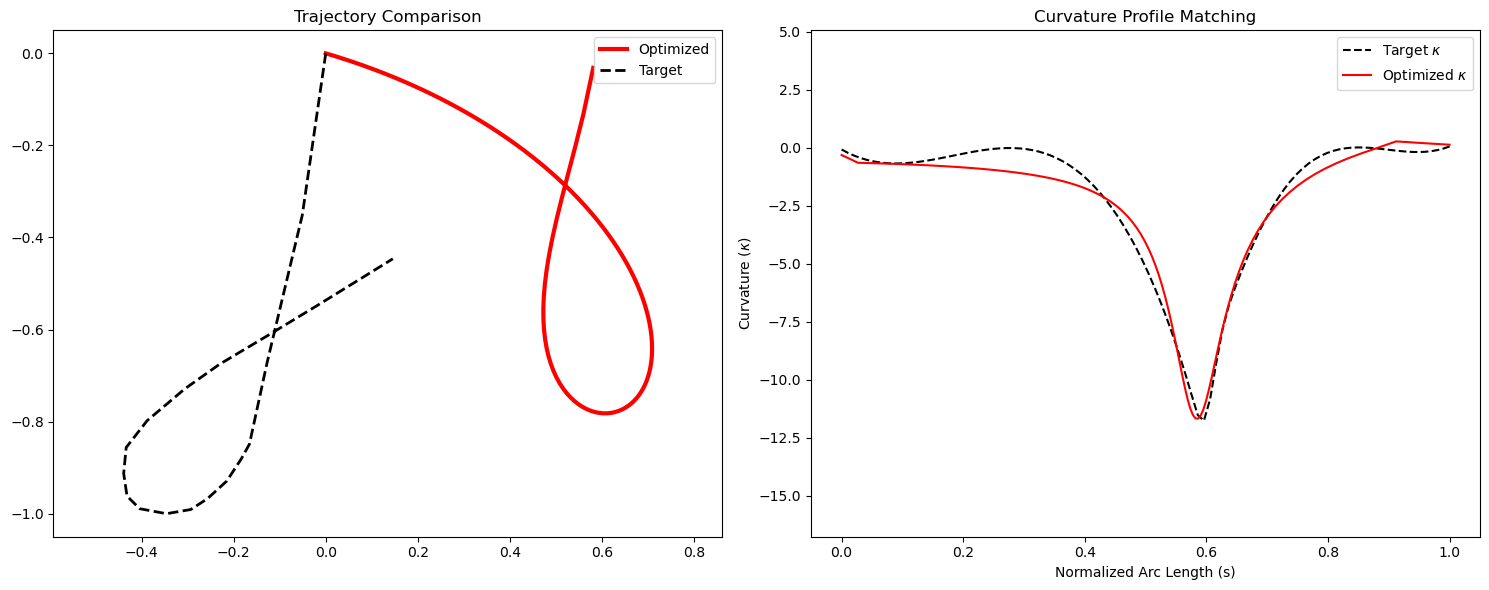

In [8]:
# ==============================================================================
# 3. EXECUTION & TRAINING LOOP
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# A. Get Target
target_k, x_scaled, y_scaled, target_L = get_real_target_curvature(device)
print(f"Target Length: {target_L.item():.4f}")

# B. Setup Model
model = StaticDesignOptimizer(n_units=30, steps=100, psi_range=(160, 45)).to(device)
optimizer = optim.Adam([
    {'params': model.alpha_params, 'lr': 0.01/2},
    {'params': model.log_l, 'lr': 0.01}
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=500, factor=0.5)

print("Starting Optimization...")
MIN_PHI_RAD = np.deg2rad(10)
EPOCHS = 8000*3

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Forward Kinematics
    traj, phi_matrix = model()

    # --- Model curvature ---
    kappa_model, s_model = model.compute_curvature_arclength(traj)
    s_target = torch.linspace(0, 1, target_k.shape[0], device=device)
    
    # Align model curvature to target grid (Arc-length alignment)
    kappa_model_rs = resample_to_target(kappa_model, s_model, s_target)

    # --- Main Objectives ---
    # 1. Curvature matching term
    loss_mse = torch.mean((kappa_model_rs - target_k)**2)
    
    # 2. Smoothness regularization (lambda_sm)
    loss_smooth = torch.mean(torch.diff(model.get_alpha())**2)
    
    # 3. Arc-length consistency (lambda_L)
    d_traj = torch.diff(traj, dim=0)
    actual_L = torch.sum(torch.norm(d_traj, dim=1))
    loss_len = ((actual_L - target_L) / target_L)**2
    
    loss_main = loss_mse + 0.001 * loss_smooth + 100 * loss_len
    
    # --- Distance to Locking (DL) Hinge Constraint ---
    # Penalize if internal angle phi < 10 degrees (Steric penalty)
    violation = torch.nn.functional.relu(MIN_PHI_RAD - phi_matrix)
    loss_DL = torch.sum(violation ** 2)

    # Combine losses
    loss = loss_main + 100000.0 * loss_DL
    
    # Gradient Descent (derivatives are handled by autograd)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step(loss)
    
    if epoch % 1000 == 0:
        min_angle_deg = np.rad2deg(phi_matrix.min().item())
        print(f"Epoch {epoch:04d} | Total Loss: {loss.item():.4f} | Min Phi (deg): {min_angle_deg:.2f} | k_mse: {loss_mse:.2f}")

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
with torch.no_grad():
    final_traj, phi = model()
    actual_k, s_final = model.compute_curvature_arclength(final_traj)
    
    actual_traj = final_traj.cpu().numpy()
    actual_k_np = actual_k.cpu().numpy()
    s_final_np = s_final.cpu().numpy()
    
    target_k_np = target_k.cpu().numpy()
    s_target_np = np.linspace(0, 1, len(target_k_np))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(actual_traj[:, 0] - actual_traj[0,0], actual_traj[:, 1] - actual_traj[0,1], 
         'r-', label=f"Optimized", lw=3)
ax1.plot(x_scaled - x_scaled[0], y_scaled - y_scaled[0], 
         'k--', label="Target", lw=2)
ax1.set_title("Trajectory Comparison")
ax1.axis('equal')
ax1.legend()

ax2.plot(s_target_np, target_k_np, 'k--', label="Target $\kappa$")
ax2.plot(s_final_np, actual_k_np, 'r-', label="Optimized $\kappa$")
ax2.set_title("Curvature Profile Matching")
ax2.set_xlabel("Normalized Arc Length (s)")
ax2.set_ylabel("Curvature ($\kappa$)")
ax2.set_ylim(target_k_np.min()-5, target_k_np.max()+5)
ax2.legend()

plt.tight_layout()
plt.show()
